# Modelling Credit Card Fraud

This notebook continues from the Exploratory Data Analysis (EDA) done in [`dataCollections.ipynb`](dataCollections.ipynb). In this part, we wish to use machine learning techniques to extract valuable insights from the data and apply various models to see which ones perform the best at predicting fraud.

## Setup
First, we reload the data and the corresponding libraries needed along with initializing a random seed.


In [2]:
%load_ext autoreload
%autoreload 2

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

seed = 31415
np.random.seed(seed)

path = kagglehub.dataset_download('whenamancodes/fraud-detection')
df = pd.read_csv(path + '/creditcard.csv')

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\_strptime.py' for module '_strptime': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Faded\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "C:\Users\Faded\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~

## Preproccessing

In the preprocessing stage, we wish to transform the amounts field to an appropriate range. This is done since features V1-V28 are obtained by PCA.

In [4]:
df_t = df.copy()

# Robust scaler since we have many outliers.
scaler = RobustScaler()

# Temporary since we will scale later
df_t['Amount_scaled'] = df_t['Amount']

df_t['Hour'] = (df_t['Time'] % 86400) / 3600

# Get rid of redundant
df_t = df_t.drop(columns=['Time','Amount'])

## Train/Test Split

Next we split the data into 80% training data and 20% test data. This ensures that we can adequately train our models while leaving a large enough test sample to evaluate the models.

In [5]:
print("df_t columns:", df_t.columns.tolist())
print("df columns:", df.columns.tolist())

df_t columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Hour']
df columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [6]:
X = df_t.drop('Class', axis=1)
y = df_t['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=seed
)

X_train[['Amount_scaled', 'Hour']] = scaler.fit_transform(X_train[['Amount_scaled', 'Hour']])
X_test[['Amount_scaled', 'Hour']] = scaler.transform(X_test[['Amount_scaled', 'Hour']])

In [7]:
print(f"Train: {X_train.shape}, fraud rate: {y_train.mean()*100:.3f}%")
print(f"Test:  {X_test.shape}, fraud rate: {y_test.mean()*100:.3f}%")
print("\nScaled columns:")
print(X_train[['Amount_scaled', 'Hour']].describe())

Train: (227845, 30), fraud rate: 0.173%
Test:  (56962, 30), fraud rate: 0.172%

Scaled columns:
       Amount_scaled           Hour
count  227845.000000  227845.000000
mean        0.926642      -0.053893
std         3.541310       0.670046
min        -0.307994      -1.721776
25%        -0.230015      -0.505352
50%         0.000000       0.000000
75%         0.769985       0.494648
max       359.361053       1.030454


## Handling Class Imbalance

Since the dataset has 0.17% fraudulent activity, the data is extremely imbalanced. To address this we use the Synthetic Minority Over-sampling Technique otherwise known as SMOTE. This technique generates synthetic samples for the fraud class, via interpolation of other points. Without handling the class imbalance, all models would predict legitimate transactions repeatedly since there are almost no fraud classes relevant to legitimate ones. We also run RandomUnderSampler to use undersampling by throwing away legit transactions until we have a balanced data set. The advantage to undersampling is that we do not create synthetic data, but we suffer from having to disregard 99% of the data. In order to select the best approach, we will compare all three options of undersampling, SMOTE, and keeping the original data.

In [8]:
sm = SMOTE(random_state=seed)
X_train_smote, y_train_smote = sm.fit_resample(X_train,y_train)

rus = RandomUnderSampler(random_state=seed)
X_train_drop, y_train_drop = rus.fit_resample(X_train, y_train)

(model, x_test, y_test, model_name='Model')
Logistic Regression Evaluation:
Accuracy: 0.9772
Precision: 0.0652
Recall: 0.9184
F1 Score: 0.1217
ROC AUC Score: 0.9762


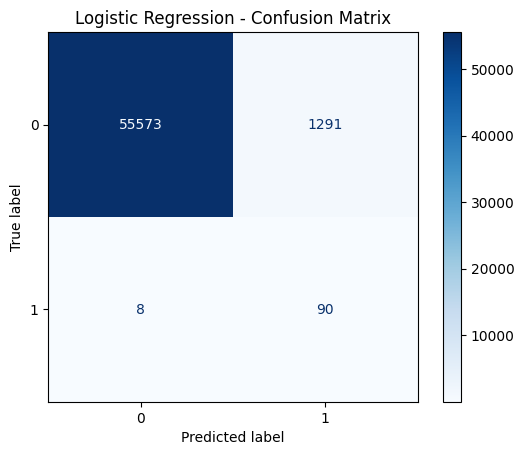

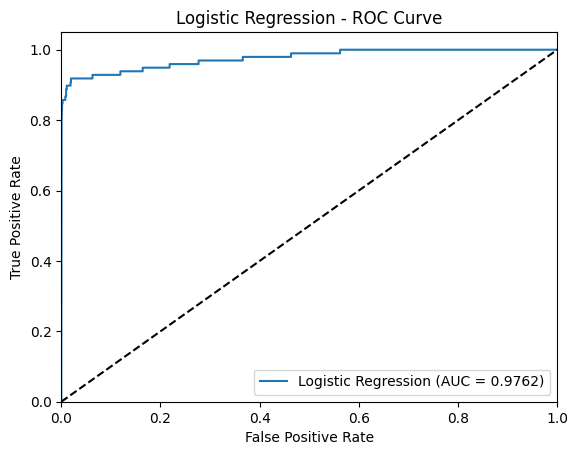

In [11]:
import sys
sys.path.append("../python") 
import inspect

from model_functions import evaluate_model

logreg = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=seed)
logreg.fit(X_train,y_train)
# Call evaluate metric = evaluate('Logistic Regression', logreg, X_test, y_test)

# Keep all metrics in results for later comparison.
# results.append(metric)



print(inspect.signature(evaluate_model))
evaluate_model(logreg, X_test, y_test, 'Logistic Regression') 
# High false positive 
